In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import cKDTree
from scipy.stats import gaussian_kde, mannwhitneyu
import pymaid

plt.style.use("seaborn-v0_8-whitegrid")

BASE_PATH      = os.path.expanduser("~/Downloads/")
CP1V_ANNOT     = "CP1v"
CP1D_ANNOT     = "CP1d"
DIST_THRESHOLD = 300
ALPHA          = 0.05
GABA_THRESHOLD = 40

# Loads all required Python libraries
# numpy and pandas for data handling
# matplotlib for plotting
# cKDTree from scipy.spatial — used to efficiently find the nearest fluorescence point to each soma
# gaussian_kde — fits smooth curves to distance distributions for plotting
# mannwhitneyu — non-parametric statistical test comparing two groups
# pymaid — connects to CATMAID and fetches neuron data
# Sets key parameters: file path, annotation names, distance threshold (300 voxels), significance level (0.05)


In [2]:
gaba_rm = pymaid.CatmaidInstance(
    server="https://neurophyla.mrc-lmb.cam.ac.uk/catmaid/fibsem/",
    api_token="ffa463360b6032c9528a020209097ef0609b6243",
    http_user="imakkar",
    http_password="daunting-cynical-hurdles",
    project_id=7,
)
print("Connected.")

# Creates a connection to the CATMAID server using your credentials
# Points specifically at project 7, which is the GABA/vGAT fluorescence volume
# This connection is reused by all later cells that need to fetch neuron data


INFO  : Global CATMAID instance set. Caching is ON. (pymaid)


Connected.


In [3]:
soma_locs = pd.read_csv(os.path.join(BASE_PATH, "soma_locs.csv"))
soma_locs["skid"] = soma_locs["skid"].astype(str)
print(f"Loaded {len(soma_locs)} somas")

fluo = np.load(os.path.join(BASE_PATH, "smallROIFluorescence_values_raw_5x5x1.npy"))
fluo[:, 0] *= 32
fluo[:, 1] *= 32
fluo[:, 2] *= 32
fluo_df = pd.DataFrame(fluo, columns=["z", "y", "x", "fluorescence"])
print(f"Loaded {len(fluo_df)} fluorescence points")

# Loads soma_locs.csv — a table of every neuron's soma x/y/z coordinates in the EM volume,
# generated by the original fluorescence script
# Loads smallROIFluorescence_values_raw_5x5x1.npy — a 3D grid of fluorescence measurements
# registered to the same EM coordinate space
# Multiplies the fluorescence coordinates by 32 to convert from voxel units to the same
# scale as the EM soma coordinates
# Stores fluorescence data as a DataFrame with columns z, y, x, fluorescence


Loaded 2014 somas
Loaded 11261 fluorescence points


In [4]:
def get_lineage_fluorescence(annot_name, soma_locs, fluo_df,
                              dist_threshold=DIST_THRESHOLD):
    ns    = pymaid.find_neurons(annotations=[annot_name], remote_instance=gaba_rm)
    skids = [str(s) for s in ns.skeleton_id]
    print(f"{annot_name}: {len(skids)} neurons in CATMAID")

    df = soma_locs[soma_locs["skid"].isin(skids)].copy()
    print(f"{annot_name}: {len(df)} somas in soma_locs.csv")

    if df.empty:
        print(f"WARNING: no somas found for {annot_name}")
        return df

    tree   = cKDTree(fluo_df[["x", "y", "z"]].values)
    d, idx = tree.query(df[["x_raw", "y_raw", "z_raw"]].values)

    df["fluorescence"] = fluo_df.iloc[idx]["fluorescence"].values
    df["match_dist"]   = d


    n_before = len(df)
    df = df[df["match_dist"] < dist_threshold].copy()
    print(f"{annot_name}: kept {len(df)}/{n_before} (threshold={dist_threshold} voxels)\n")

    df["hemilineage"] = annot_name
    return df

# Defines a reusable function that takes a CATMAID annotation name (e.g. "CP1v") and
# returns a table of neurons with their fluorescence values attached
# Step 1: Queries CATMAID to find all skeleton IDs with the given annotation
# Step 2: Filters soma_locs down to just those skeleton IDs to get their soma coordinates
# Step 3: Builds a cKDTree from all fluorescence points — a spatial data structure that
#         allows very fast nearest-neighbour lookups (same method as the original fluorescence script)
# Step 4: For each soma, queries the tree to find the single closest fluorescence point
#         and records both the fluorescence value and the distance to that point
# Step 5: Drops any neurons whose nearest fluorescence point is further than 300 voxels —
#         these fall outside the registered fluorescence volume and would return unreliable values
# Returns a DataFrame with columns: skid, x_raw, y_raw, z_raw, fluorescence, match_dist, hemilineage


In [5]:
[item * 12 for item in [3648.0,2400,5024.0]]

[43776.0, 28800, 60288.0]

In [6]:
np.array([2624.0,2080.0,4736.0]) * 12

array([31488., 24960., 56832.])

In [7]:
pymaid.clear_cache()

cp1v_df = get_lineage_fluorescence(CP1V_ANNOT, soma_locs, fluo_df)
cp1d_df = get_lineage_fluorescence(CP1D_ANNOT, soma_locs, fluo_df)

cp1_df = pd.concat([cp1v_df, cp1d_df], ignore_index=True)
print(cp1_df[["skid", "hemilineage", "fluorescence", "match_dist"]])

# Calls the helper function twice — once for CP1v, once for CP1d
# Combines both results into a single DataFrame cp1_df with a hemilineage column
# Prints the full table so you can inspect fluorescence values and match distances
# for every neuron before proceeding


INFO  : Cached cleared. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)


Make nrn:   0%|          | 0/20 [00:00<?, ?it/s]

INFO  : Found 20 neurons matching the search parameters (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)


CP1v: 20 neurons in CATMAID
CP1v: 20 somas in soma_locs.csv
CP1v: kept 20/20 (threshold=300 voxels)



Make nrn:   0%|          | 0/12 [00:00<?, ?it/s]

INFO  : Found 12 neurons matching the search parameters (pymaid)


CP1d: 12 neurons in CATMAID
CP1d: 12 somas in soma_locs.csv
CP1d: kept 12/12 (threshold=300 voxels)

      skid hemilineage  fluorescence  match_dist
0    20638        CP1v         33.92   30.148189
1    16657        CP1v         18.64   49.841380
2    20896        CP1v         79.04   44.342501
3    13137        CP1v         53.00   28.137840
4   255273        CP1v         55.12   27.433389
5   255463        CP1v         56.20   42.973570
6   296632        CP1v         58.00   77.088486
7   296636        CP1v         14.96   22.052357
8   296640        CP1v         78.00   45.312756
9   296644        CP1v         16.92   39.714262
10  296648        CP1v         44.96   31.672295
11  296652        CP1v         15.16   35.093465
12  296656        CP1v         17.04   31.412943
13  296660        CP1v         11.84   92.345442
14  296669        CP1v         12.20   26.716710
15  296678        CP1v         49.76   39.209212
16  296693        CP1v         14.24   27.320951
17   14355       

In [8]:
cp1d_df

,x,y,z,skid,x_raw,y_raw,z_raw,closest_fluo_idx,closest_fluo_dist,fluorescence,fluo_x,fluo_y,fluo_z,match_dist,hemilineage
59,37110.960,27102.803,67812.00,20583,3092.5800,2258.5670,5651.0000,4791,28.916158,75.56,3104.0,2240.0,5632.0,28.916256,CP1d
65,36233.324,29818.992,70044.00,20593,3019.4436,2484.9160,5837.0000,4914,24.795378,29.28,3008.0,2496.0,5856.0,24.795383,CP1d
73,37447.766,31084.623,63036.00,20608,3120.6472,2590.3853,5253.0000,4561,17.456725,25.60,3104.0,2592.0,5248.0,17.456704,CP1d
77,43379.523,24770.365,62652.00,20614,3614.9602,2064.1970,5221.0000,4494,16.983070,19.00,3616.0,2048.0,5216.0,16.983050,CP1d
81,33830.168,31886.490,61968.00,20626,2819.1807,2657.2075,5164.0000,4479,38.895449,55.20,2816.0,2624.0,5184.0,38.895436,CP1d
83,38540.290,30061.752,65616.00,20632,3211.6907,2505.1460,5468.0000,4703,15.372739,47.20,3200.0,2496.0,5472.0,15.372761,CP1d
97,40493.150,28471.180,58788.00,20662,3374.4290,2372.5984,4899.0000,4155,15.438262,95.48,3360.0,2368.0,4896.0,15.438307,CP1d
103,38082.387,26852.658,60708.00,20672,3173.5322,2237.7214,5059.0000,4369,35.507709,72.48,3168.0,2240.0,5024.0,35.507707,CP1d
111,37584.000,25608.000,63096.00,20692,3132.0000,2134.0000,5258.0000,4588,36.986484,16.64,3104.0,2112.0,5248.0,36.986484,CP1d
118,44436.000,28170.960,64368.00,20706,3703.0000,2347.5800,5364.0000,4614,32.605187,48.16,3680.0,2336.0,5344.0,32.605159,CP1d


In [9]:
cp1v_df

,x,y,z,skid,x_raw,y_raw,z_raw,closest_fluo_idx,closest_fluo_dist,fluorescence,fluo_x,fluo_y,fluo_z,match_dist,hemilineage
85,40149.330,25986.785,64632.0,20638,3345.7773,2165.5654,5386.0000,4657,30.148204,33.92,3328.0,2176.0,5408.0,30.148189,CP1v
143,35577.520,30772.445,51396.0,16657,2964.7932,2564.3704,4283.0000,3418,49.841357,18.64,2944.0,2528.0,4256.0,49.841380,CP1v
216,39760.320,31092.021,69024.0,20896,3313.3600,2591.0017,5752.0000,4870,44.342536,79.04,3296.0,2624.0,5728.0,44.342501,CP1v
444,38765.043,25755.475,55632.0,13137,3230.4202,2146.2896,4636.0000,3860,28.137838,53.00,3232.0,2144.0,4608.0,28.137840,CP1v
706,39720.000,35775.030,60564.0,255273,3310.0000,2981.2527,5047.0000,4344,27.433387,55.12,3296.0,2976.0,5024.0,27.433389,CP1v
806,40511.750,32968.720,58716.0,255463,3375.9792,2747.3933,4893.0000,4178,42.973595,56.20,3360.0,2720.0,4864.0,42.973570,CP1v
919,38100.000,24462.098,49006.5,296632,3175.0000,2038.5082,4083.8750,3187,77.088480,58.00,3104.0,2016.0,4064.0,77.088486,CP1v
921,38808.000,32134.098,51483.5,296636,3234.0000,2677.8416,4290.2915,3498,22.052311,14.96,3232.0,2656.0,4288.0,22.052357,CP1v
924,41796.000,32741.600,63273.0,296640,3483.0000,2728.4666,5272.7500,4527,45.312747,78.00,3520.0,2720.0,5248.0,45.312756,CP1v
927,32843.000,28612.098,50688.0,296644,2736.9167,2384.3416,4224.0000,3384,39.714263,16.92,2720.0,2368.0,4256.0,39.714262,CP1v


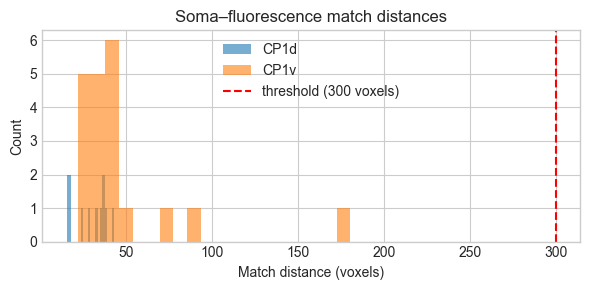

In [10]:
fig, ax = plt.subplots(figsize=(6, 3))
for name, group in cp1_df.groupby("hemilineage"):
    ax.hist(group["match_dist"], bins=20, alpha=0.6, label=name)
ax.axvline(DIST_THRESHOLD, color="red", linestyle="--",
           label=f"threshold ({DIST_THRESHOLD} voxels)")
ax.set_xlabel("Match distance (voxels)")
ax.set_ylabel("Count")
ax.set_title("Soma–fluorescence match distances")
ax.legend()
plt.tight_layout()
plt.show()

# Plots a histogram of match distances for both hemilineages
# The red dashed line marks the 300 voxel threshold
# Used to verify that all retained neurons have reliable matches —
# all bars should fall well to the left of the threshold line
# Any neurons with distances above the threshold were removed in Cell 4


In [11]:
cp1v_vals = cp1_df.loc[cp1_df["hemilineage"] == CP1V_ANNOT, "fluorescence"].values
cp1d_vals = cp1_df.loc[cp1_df["hemilineage"] == CP1D_ANNOT, "fluorescence"].values

print(f"CP1v: n={len(cp1v_vals)}, mean={cp1v_vals.mean():.2f}, median={np.median(cp1v_vals):.2f}")
print(f"CP1d: n={len(cp1d_vals)}, mean={cp1d_vals.mean():.2f}, median={np.median(cp1d_vals):.2f}")

u_stat, p_val_hemi = mannwhitneyu(cp1v_vals, cp1d_vals, alternative="two-sided")
print(f"\nMann–Whitney U={u_stat:.1f}, p={p_val_hemi:.4f}")
print(f"{'Significant difference' if p_val_hemi < ALPHA else 'No significant difference'} at alpha={ALPHA}")

# Extracts fluorescence values for CP1v and CP1d as separate arrays
# Prints mean, median, and n for each group
# Runs a Mann-Whitney U test — non-parametric, does not assume normality,
# appropriate for small sample sizes and skewed fluorescence distributions
# Tests whether the two hemilineages have significantly different fluorescence distributions
# A significant result (p < 0.05) would suggest CP1v and CP1d have different neurotransmitter
# identities, consistent with Notch signalling producing two distinct daughter populations


CP1v: n=20, mean=33.29, median=17.84
CP1d: n=12, mean=44.69, median=47.68

Mann–Whitney U=88.0, p=0.2201
No significant difference at alpha=0.05


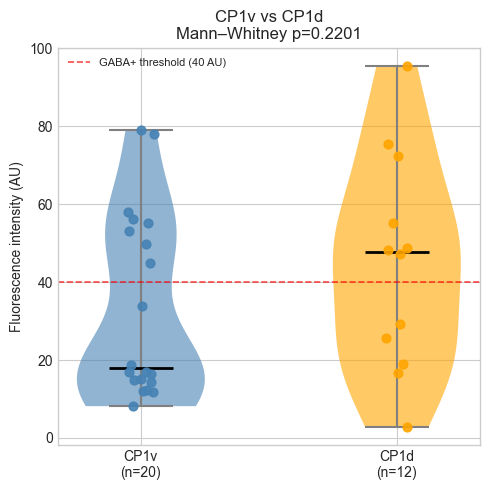

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(5, 5))

groups  = [cp1_df.loc[cp1_df["hemilineage"] == CP1V_ANNOT, "fluorescence"].values,
           cp1_df.loc[cp1_df["hemilineage"] == CP1D_ANNOT, "fluorescence"].values]
labels  = [f"{CP1V_ANNOT}\n(n={len(groups[0])})",
           f"{CP1D_ANNOT}\n(n={len(groups[1])})"]
colours = ["steelblue", "orange"]

parts = ax.violinplot(groups, positions=[0, 1], showmedians=True, bw_method=0.5)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(colours[i])
    pc.set_alpha(0.6)
parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(2)
parts["cmaxes"].set_color("grey")
parts["cmins"].set_color("grey")
parts["cbars"].set_color("grey")

for i, (data, colour) in enumerate(zip(groups, colours)):
    x_jitter = np.random.uniform(-0.05, 0.05, size=len(data)) + i
    ax.scatter(x_jitter, data, color=colour, s=40, zorder=3, alpha=0.9)

# GABA threshold line
ax.axhline(GABA_THRESHOLD, color="red", linestyle="--", linewidth=1.2,
           alpha=0.7, label=f"GABA+ threshold ({GABA_THRESHOLD} AU)")

ax.set_xticks([0, 1])
ax.set_xticklabels(labels)
ax.set_ylabel("Fluorescence intensity (AU)")
ax.set_title(f"{CP1V_ANNOT} vs {CP1D_ANNOT}\nMann–Whitney p={p_val_hemi:.4f}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "CP1_violinplot.pdf"), bbox_inches="tight")
plt.show()


In [13]:
import plotly.graph_objects as go

fig = go.Figure()

marker_symbols = {CP1V_ANNOT: "circle", CP1D_ANNOT: "diamond"}

for name, symbol in marker_symbols.items():
    group = cp1_df[cp1_df["hemilineage"] == name]
    fig.add_trace(go.Scatter3d(
        x=group["x_raw"],
        y=group["y_raw"],
        z=group["z_raw"],
        mode="markers",
        name=name,
        text=group["skid"].astype(str),
        hovertemplate="skid: %{text}<br>fluor: %{marker.color:.2f} AU<extra></extra>",
        marker=dict(
            symbol=symbol,
            size=6,
            color=group["fluorescence"],
            colorscale="Viridis",
            cmin=cp1_df["fluorescence"].min(),
            cmax=cp1_df["fluorescence"].max(),
            colorbar=dict(title="Fluorescence<br>intensity (AU)") if name == CP1V_ANNOT else None,
            opacity=0.85,
            line=dict(color="grey", width=0.5),
        )
    ))

fig.update_layout(
    title="CP1 soma positions coloured by GABA fluorescence<br>(circle=CP1v, diamond=CP1d)",
    scene=dict(
        xaxis_title="x (voxels)",
        yaxis_title="y (voxels)",
        zaxis_title="z (voxels)",
    ),
    width=900,
    height=700,
    legend=dict(x=0.01, y=0.99),
)

fig.write_html(os.path.join(BASE_PATH, "CP1_3D_fluorescence.html"))
fig.show()


In [14]:
#repeat for Cp1d and Cp1v individually - if assume to be hemilineages, could represent birth order?
#change plot to histogram
#need to create fake model data for matching and non matching to see what an actual positive result would look like 
#biologically, why would this be relevant? what is interesting about the findings? what does it show us?
#could be statistically significant, but would this be the case biologically?

CP1 (combined): matching n=241, non-matching n=255, U=29889.0, p=0.2997
CP1v only: matching n=94, non-matching n=96, U=4367.0, p=0.3515
CP1d only: matching n=31, non-matching n=35, U=571.0, p=0.6453


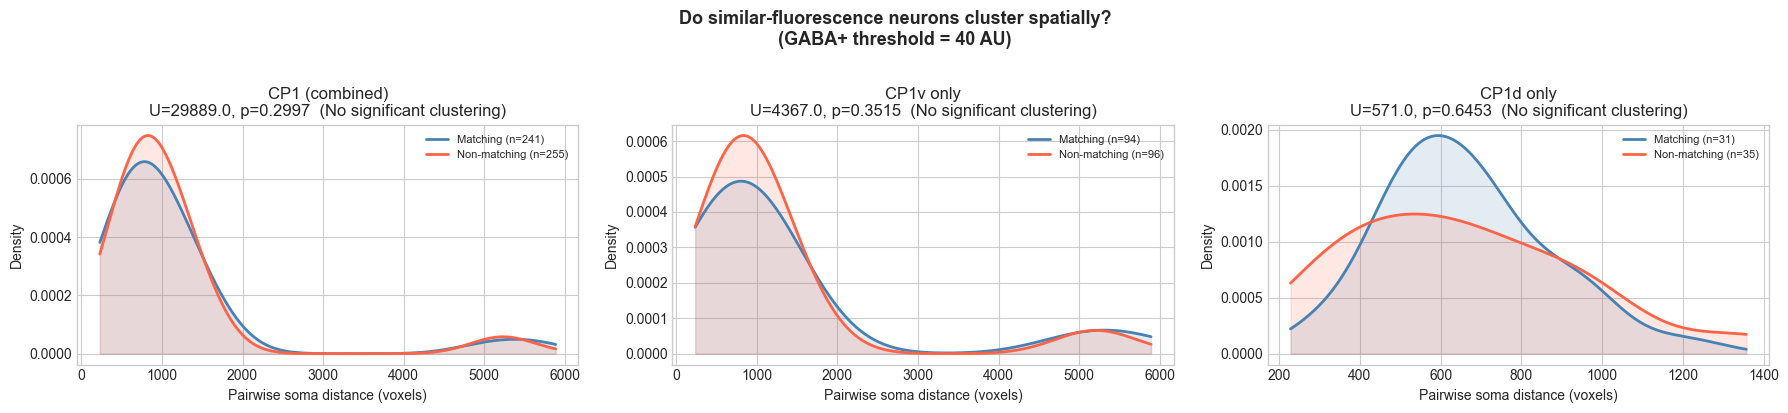

In [15]:
import itertools
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde


GABA_THRESHOLD = 40


def clustering_kde_plot(df, label, ax, alpha=0.05):
    coords    = df[["x_raw", "y_raw", "z_raw"]].values
    fluo_vals = df["fluorescence"].values


    # CHANGED: use fixed biological threshold instead of median
    rows = []
    for i, j in itertools.combinations(range(len(df)), 2):
        spatial_d = np.sqrt(((coords[i] - coords[j])**2).sum())
        both_high = fluo_vals[i] >= GABA_THRESHOLD and fluo_vals[j] >= GABA_THRESHOLD
        both_low  = fluo_vals[i] <  GABA_THRESHOLD and fluo_vals[j] <  GABA_THRESHOLD
        rows.append({"spatial_dist": spatial_d, "match": both_high or both_low})


    pairs       = pd.DataFrame(rows)
    matching    = pairs[pairs["match"]]["spatial_dist"]
    nonmatching = pairs[~pairs["match"]]["spatial_dist"]


    if len(matching) < 3 or len(nonmatching) < 3:
        ax.set_title(f"{label}\nToo few pairs to test")
        return


    u_stat, p_val = mannwhitneyu(matching, nonmatching, alternative="less")


    x_smooth = np.linspace(pairs["spatial_dist"].min(),
                           pairs["spatial_dist"].max(), 300)
    for lbl, data, colour in [
        (f"Matching (n={len(matching)})",        matching,    "steelblue"),
        (f"Non-matching (n={len(nonmatching)})", nonmatching, "tomato")
    ]:
        kde = gaussian_kde(data)
        ax.plot(x_smooth, kde(x_smooth), linewidth=2, label=lbl, color=colour)
        ax.fill_between(x_smooth, kde(x_smooth), alpha=0.15, color=colour)


    sig = "SIGNIFICANT" if p_val < alpha else "No significant clustering"
    ax.set_xlabel("Pairwise soma distance (voxels)")
    ax.set_ylabel("Density")
    ax.set_title(f"{label}\nU={u_stat:.1f}, p={p_val:.4f}  ({sig})")
    ax.legend(fontsize=8)
    print(f"{label}: matching n={len(matching)}, non-matching n={len(nonmatching)}, U={u_stat:.1f}, p={p_val:.4f}")



# --- Plot all three side by side ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))


clustering_kde_plot(cp1_df,                                        "CP1 (combined)",  axes[0])
clustering_kde_plot(cp1_df[cp1_df["hemilineage"] == CP1V_ANNOT],  "CP1v only",       axes[1])
clustering_kde_plot(cp1_df[cp1_df["hemilineage"] == CP1D_ANNOT],  "CP1d only",       axes[2])


plt.suptitle(f"Do similar-fluorescence neurons cluster spatially?\n(GABA+ threshold = {GABA_THRESHOLD} AU)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "CP1_clustering_all.pdf"), bbox_inches="tight")
plt.show()

In [19]:
def clustering_kde_plot(df, label, ax, alpha=0.05, use_threshold=True,
                        threshold=GABA_THRESHOLD):
    coords    = df[["x_raw", "y_raw", "z_raw"]].values
    fluo_vals = df["fluorescence"].values

    cutoff = threshold if use_threshold else np.median(fluo_vals)

    rows = []
    for i, j in itertools.combinations(range(len(df)), 2):
        spatial_d = np.sqrt(((coords[i] - coords[j])**2).sum())
        both_high = fluo_vals[i] >= cutoff and fluo_vals[j] >= cutoff
        both_low  = fluo_vals[i] <  cutoff and fluo_vals[j] <  cutoff
        rows.append({"spatial_dist": spatial_d, "match": both_high or both_low})

    pairs       = pd.DataFrame(rows)
    matching    = pairs[pairs["match"]]["spatial_dist"]
    nonmatching = pairs[~pairs["match"]]["spatial_dist"]

    if len(matching) < 3 or len(nonmatching) < 3:
        ax.set_title(f"{label}\nToo few pairs to test")
        return

    u_stat, p_val = mannwhitneyu(matching, nonmatching, alternative="less")

    x_smooth = np.linspace(pairs["spatial_dist"].min(),
                           pairs["spatial_dist"].max(), 300)
    for lbl, data, colour in [
        (f"Matching (n={len(matching)})",        matching,    "steelblue"),
        (f"Non-matching (n={len(nonmatching)})", nonmatching, "tomato")
    ]:
        kde = gaussian_kde(data)
        ax.plot(x_smooth, kde(x_smooth), linewidth=2, label=lbl, color=colour)
        ax.fill_between(x_smooth, kde(x_smooth), alpha=0.15, color=colour)

    sig = "SIGNIFICANT" if p_val < alpha else "No significant clustering"
    ax.set_xlabel("Pairwise soma distance (voxels)")
    ax.set_ylabel("Density")
    ax.set_title(f"{label}\nU={u_stat:.1f}, p={p_val:.4f}  ({sig})")
    ax.legend(fontsize=8)
    print(f"{label}: matching n={len(matching)}, non-matching n={len(nonmatching)}, U={u_stat:.1f}, p={p_val:.4f}")

(b) Model data (partial clustering): matching n=90, non-matching n=100, U=4.0, p=0.0000
(c) CP1 (real data): matching n=241, non-matching n=255, U=29889.0, p=0.2997


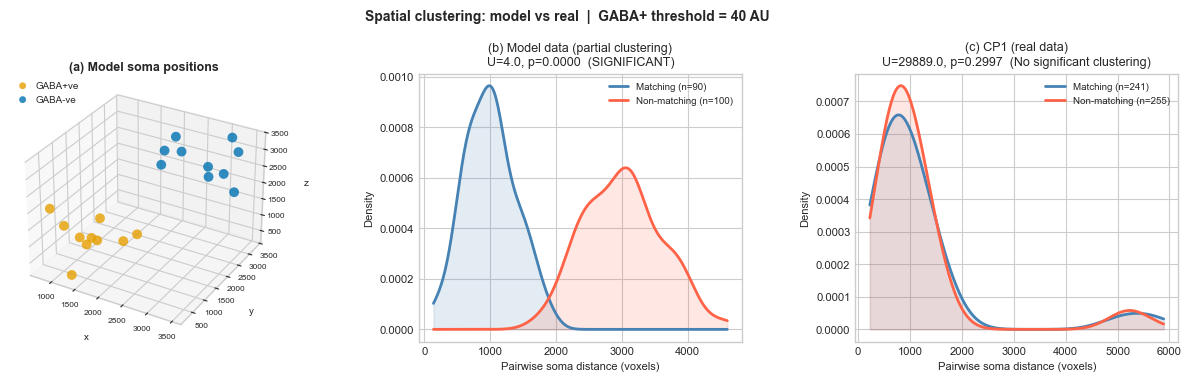

In [23]:
import matplotlib.gridspec as gridspec

# Colorblind-safe (Okabe-Ito)
CB_ORANGE = "#E69F00"
CB_BLUE   = "#0072B2"

GABA_THRESHOLD = 40
np.random.seed(42)
n_per_group = 10

# Imperfect separation: closer centres + larger spread
pos_high  = np.random.normal(loc=1200, scale=500, size=(n_per_group, 3))
fluo_high = np.random.uniform(45, 90, n_per_group)
pos_low   = np.random.normal(loc=2800, scale=500, size=(n_per_group, 3))
fluo_low  = np.random.uniform(5, 45, n_per_group)

model_df = pd.DataFrame(np.vstack([pos_high, pos_low]), columns=["x_raw", "y_raw", "z_raw"])
model_df["fluorescence"] = np.concatenate([fluo_high, fluo_low])

fig = plt.figure(figsize=(13, 4))

gs = gridspec.GridSpec(
    1, 3,
    figure=fig,
    wspace=0.35,
    left=0.05,
    right=0.97,
    top=0.82,
    bottom=0.15
)

# ── Panel (a): 3D scatter ─────────────────────────────────────────────────────
ax3d = fig.add_subplot(gs[0, 0], projection="3d")
ax3d.scatter(pos_high[:, 0], pos_high[:, 1], pos_high[:, 2],
             c=CB_ORANGE, s=50, label="GABA+ve", alpha=0.8, edgecolors="none")
ax3d.scatter(pos_low[:, 0],  pos_low[:, 1],  pos_low[:, 2],
             c=CB_BLUE,   s=50, label="GABA-ve", alpha=0.8, edgecolors="none")
ax3d.set_title("(a) Model soma positions", fontsize=9, fontweight="bold", pad=2)
ax3d.set_xlabel("x", fontsize=7, labelpad=-2)
ax3d.set_ylabel("y", fontsize=7, labelpad=-2)
ax3d.set_zlabel("z", fontsize=7, labelpad=-2)
ax3d.tick_params(labelsize=6, pad=-2)
ax3d.legend(fontsize=7, loc="upper left", markerscale=0.7,
            borderpad=0.3, handlelength=1)
ax3d.dist = 11

# ── Panel (b): KDE model ──────────────────────────────────────────────────────
ax_model = fig.add_subplot(gs[0, 1])
clustering_kde_plot(model_df, "(b) Model data (partial clustering)", ax_model)

# ── Panel (c): KDE real ───────────────────────────────────────────────────────
ax_real = fig.add_subplot(gs[0, 2])
clustering_kde_plot(cp1_df, "(c) CP1 (real data)", ax_real)

for ax in [ax_model, ax_real]:
    ax.tick_params(labelsize=8)
    ax.set_xlabel(ax.get_xlabel(), fontsize=8)
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)
    ax.title.set_fontsize(9)
    ax.legend(fontsize=7)

fig.suptitle(
    f"Spatial clustering: model vs real  |  GABA+ threshold = {GABA_THRESHOLD} AU",
    fontsize=10, fontweight="bold"
)

plt.savefig(os.path.join(BASE_PATH, "CP1_clustering_model_vs_real.pdf"),
            bbox_inches="tight")
plt.show()

In [ ]:
from scipy.stats import shapiro

def test_normality(data, label, alpha=ALPHA):
    stat, p = shapiro(data)
    normal = p > alpha
    print(f"  {label}: W={stat:.4f}, p={p:.4f} → {'Normal' if normal else 'NOT normal'}")
    return normal

# --- CP1v vs CP1d fluorescence ---
cp1v_vals = cp1_df.loc[cp1_df["hemilineage"] == CP1V_ANNOT, "fluorescence"]
cp1d_vals = cp1_df.loc[cp1_df["hemilineage"] == CP1D_ANNOT, "fluorescence"]

print("=== Shapiro-Wilk: CP1 Hemilineage Fluorescence ===")
norm_v = test_normality(cp1v_vals, f"CP1v (n={len(cp1v_vals)})")
norm_d = test_normality(cp1d_vals, f"CP1d (n={len(cp1d_vals)})")
print(f"→ Mann-Whitney U justified: {not (norm_v and norm_d)}")

=== Shapiro-Wilk: CP1 Hemilineage Fluorescence ===
  CP1v (n=20): W=0.8382, p=0.0034 → NOT normal
  CP1d (n=12): W=0.9685, p=0.8943 → Normal
→ Mann-Whitney U justified: True


Power of current CP1 clustering test
  n neurons  : 32  →  496 pairs
  n matching : 241  |  n non-matching: 255
-------------------------------------------------------
  Small (r=0.1)        → power = 0.611 (61.1%)
  Medium (r=0.3)       → power = 1.000 (100.0%)
  Large (r=0.5)        → power = 1.000 (100.0%)

Neurons required for 80% power (one-tailed, α=0.05)
-------------------------------------------------------
  Small (r=0.1)        → n = 42 neurons (861 pairs), power = 0.814
  Medium (r=0.3)       → n = 15 neurons (105 pairs), power = 0.839
  Large (r=0.5)        → n = 9 neurons (36 pairs), power = 0.821


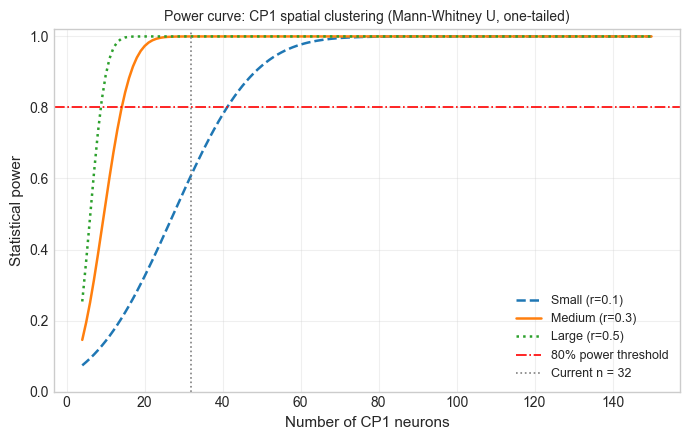

In [ ]:
# ── Statistical Power Analysis: CP1 Spatial Clustering (Mann-Whitney U) ──────
from scipy import stats
from scipy.special import ndtri
import numpy as np
import matplotlib.pyplot as plt

# ── Known values from the CP1 clustering result ──────────────────────────────
n_neurons  = 32          # total CP1 neurons (12 CP1d + 20 CP1v)
n_match    = 241         # matching pairs (same GABA class)
n_nonmatch = 255         # non-matching pairs
# Sanity check: C(32,2) = 32*31/2 = 496 ✓
assert n_match + n_nonmatch == n_neurons * (n_neurons - 1) // 2

# ── Effect size conventions (rank-biserial correlation r) ─────────────────────
# r = 0.1 small, r = 0.3 medium, r = 0.5 large  (Cohen 1988 adapted for MWU)
# Power approximation for one-tailed Mann-Whitney U via normal approximation:
# z_power = z_alpha + r * sqrt(n1 * n2 * (n1 + n2 + 1) / 3) / sqrt(n1*n2/2)
# Simplified: power = Φ( -z_alpha + r * sqrt(n1 * n2 * (n1+n2+1) / 3) )

def mwu_power(n1, n2, effect_r, alpha=0.05, one_tailed=True):
    """
    Normal approximation power for Mann-Whitney U test.
    effect_r: rank-biserial correlation (0.1=small, 0.3=med, 0.5=large)
    """
    z_alpha  = ndtri(1 - alpha) if one_tailed else ndtri(1 - alpha / 2)
    var_null = n1 * n2 * (n1 + n2 + 1) / 12
    # Non-centrality: expected U shift under H1
    delta_U  = effect_r * n1 * n2 / 2
    z_power  = (delta_U - z_alpha * np.sqrt(var_null)) / np.sqrt(var_null)
    return stats.norm.cdf(z_power)

def neurons_for_power(target_power, effect_r, alpha=0.05, max_neurons=200):
    """
    Find minimum number of neurons (n) such that C(n,2) pairs yield target power.
    Assumes equal split of matching/non-matching pairs (C(n,2)/2 each) as a 
    conservative approximation.
    """
    for n in range(4, max_neurons):
        n_pairs   = n * (n - 1) // 2
        n1 = n2   = n_pairs // 2
        p = mwu_power(n1, n2, effect_r, alpha)
        if p >= target_power:
            return n, n_pairs, p
    return None, None, None

# ── 1. Power of the current test ─────────────────────────────────────────────
print("=" * 55)
print("Power of current CP1 clustering test")
print(f"  n neurons  : {n_neurons}  →  {n_match + n_nonmatch} pairs")
print(f"  n matching : {n_match}  |  n non-matching: {n_nonmatch}")
print("-" * 55)
for label, r in [("Small (r=0.1)", 0.1), ("Medium (r=0.3)", 0.3), ("Large (r=0.5)", 0.5)]:
    power = mwu_power(n_match, n_nonmatch, r)
    print(f"  {label:20s} → power = {power:.3f} ({power*100:.1f}%)")

# ── 2. Neurons required for 80% power ────────────────────────────────────────
print("\n" + "=" * 55)
print("Neurons required for 80% power (one-tailed, α=0.05)")
print("-" * 55)
for label, r in [("Small (r=0.1)", 0.1), ("Medium (r=0.3)", 0.3), ("Large (r=0.5)", 0.5)]:
    n, n_pairs, achieved = neurons_for_power(0.80, r)
    print(f"  {label:20s} → n = {n} neurons ({n_pairs} pairs), power = {achieved:.3f}")

# ── 3. Power curve vs number of neurons ──────────────────────────────────────
neuron_range = np.arange(4, 151)
fig, ax = plt.subplots(figsize=(7, 4.5))

for label, r, ls in [("Small (r=0.1)", 0.1, '--'),
                      ("Medium (r=0.3)", 0.3, '-'),
                      ("Large (r=0.5)", 0.5, ':')]:
    powers = []
    for n in neuron_range:
        n_pairs = n * (n - 1) // 2
        powers.append(mwu_power(n_pairs // 2, n_pairs - n_pairs // 2, r))
    ax.plot(neuron_range, powers, linestyle=ls, label=label, linewidth=1.8)

ax.axhline(0.80, color='red', linestyle='-.', linewidth=1.2, label='80% power threshold')
ax.axvline(n_neurons, color='gray', linestyle=':', linewidth=1.2,
           label=f'Current n = {n_neurons}')
ax.set_xlabel('Number of CP1 neurons', fontsize=11)
ax.set_ylabel('Statistical power', fontsize=11)
ax.set_title('Power curve: CP1 spatial clustering (Mann-Whitney U, one-tailed)',
             fontsize=10)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cp1_power_curve.png', dpi=150, bbox_inches='tight')
plt.show()